In [38]:
# Import Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re
import string

# For preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download once

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
folder_path = "/content/drive/MyDrive/CS410_Final_Project"
print(os.listdir(folder_path))
file_path = "/content/drive/MyDrive/CS410_Final_Project/IMDB_movies.csv"



['EDA_Data_Preprocessing.ipynb', 'IMDB_movies.csv', 'Final Project Doc.docx']


In [29]:
# Dataset Loading
df = pd.read_csv(file_path)

df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9957 entries, 0 to 9956
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        9957 non-null   object 
 1   year         9430 non-null   object 
 2   certificate  6504 non-null   object 
 3   duration     7921 non-null   object 
 4   genre        9884 non-null   object 
 5   rating       8784 non-null   float64
 6   description  9957 non-null   object 
 7   stars        9957 non-null   object 
 8   votes        8784 non-null   object 
dtypes: float64(1), object(8)
memory usage: 700.2+ KB


,0
title,0
year,527
certificate,3453
duration,2036
genre,73
rating,1173
description,0
stars,0
votes,1173


In [30]:
# Data Cleaning

df = df.drop_duplicates()
print(df.isnull().sum())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

#Convert nan strings to actual Nan
for col in df.columns:
    df[col] = df[col].replace("nan", np.nan)

#We disregard the null values for our important fields
df = df.dropna(subset=['description'])
df['genre'] = df['genre'].fillna('')
df['stars'] = df['stars'].fillna('')
df['title'] = df['title'].fillna('')
df['certificate'] = df['certificate'].fillna('Unknown')

print(df.shape)

title             0
year            527
certificate    3453
duration       2036
genre            73
rating         1173
description       0
stars             0
votes          1173
dtype: int64
(9957, 9)


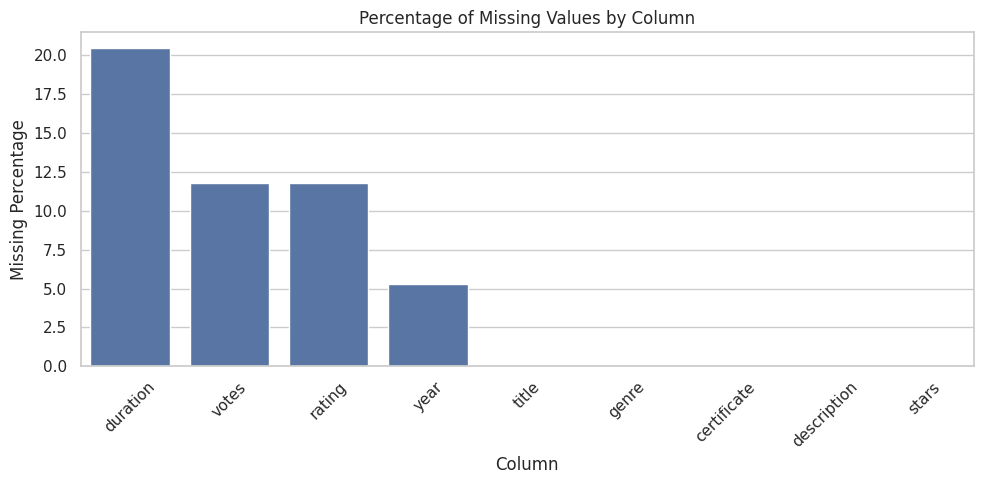

In [31]:
# Missing values plot
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'column': missing_counts.index,
    'missing_count': missing_counts.values,
    'missing_percent': missing_percent.values
}).sort_values(by='missing_percent', ascending=False)

missing_df
plt.figure(figsize=(10, 5))
sns.barplot(data=missing_df, x='column', y='missing_percent')
plt.xticks(rotation=45)
plt.title("Percentage of Missing Values by Column")
plt.ylabel("Missing Percentage")
plt.xlabel("Column")
plt.tight_layout()
plt.show()

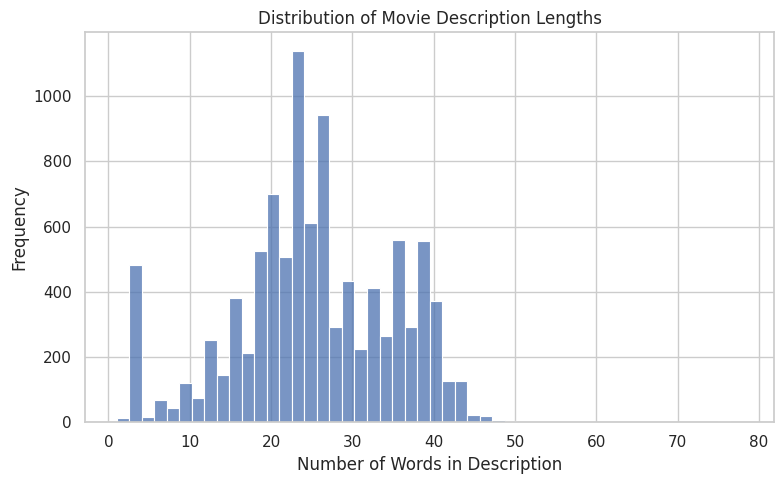

,desc_length_words
count,9957.000000
mean,25.400824
std,9.826382
min,1.000000
25%,20.000000
50%,25.000000
75%,33.000000
max,78.000000


In [32]:
# Exploratory Data Analysis

#Description Length Analysis
df['desc_length_words'] = df['description'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 5))
sns.histplot(df['desc_length_words'], bins=50)
plt.title("Distribution of Movie Description Lengths")
plt.xlabel("Number of Words in Description")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

df['desc_length_words'].describe()

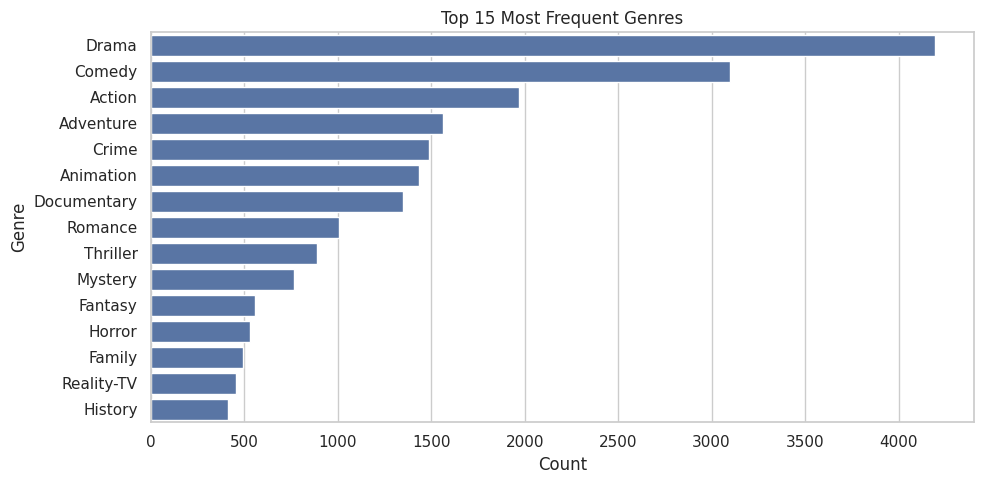

,count
genre,
Drama,4194
Comedy,3098
Action,1969
Adventure,1563
Crime,1491
Animation,1434
Documentary,1349
Romance,1007
Thriller,889


In [33]:
# Genre Analysis
genre_series = df['genre'].dropna().astype(str).str.split(',').explode().str.strip()
top_genres = genre_series.value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 15 Most Frequent Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

top_genres

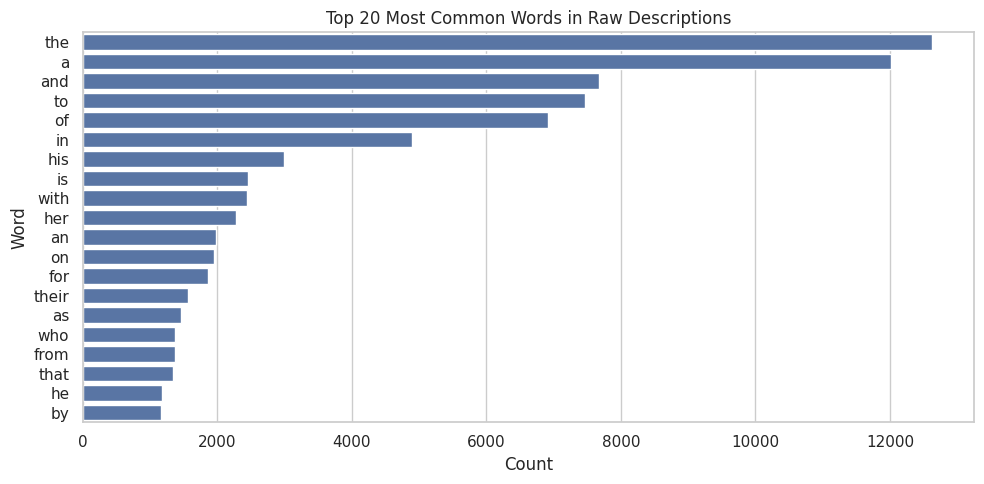

In [34]:
# Word Frequency Pre-Cleaning

raw_text = " ".join(df['description'].astype(str).tolist()).lower()
raw_tokens = raw_text.split()

word_counts = Counter(raw_tokens)
common_words = word_counts.most_common(20)

common_words_df = pd.DataFrame(common_words, columns=['word', 'count'])
common_words_df

plt.figure(figsize=(10, 5))
sns.barplot(data=common_words_df, x='count', y='word')
plt.title("Top 20 Most Common Words in Raw Descriptions")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

In [39]:
# Description text cleaning function

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token.isalpha()]
    tokens = [token for token in tokens if token not in stop_words]
    return " ".join(tokens)

In [40]:
# Create cleaned_description, and clean other important fields like genre and actor

df['clean_description'] = df['description'].apply(clean_text)

df[['description', 'clean_description']].head(3)

,description,clean_description
0,Decades after their 1984 All Valley Karate Tou...,decades valley karate tournament bout middle a...
1,Follows the political rivalries and romance of...,follows political rivalries romance queen eliz...
2,The trials and tribulations of criminal lawyer...,trials tribulations criminal lawyer jimmy mcgi...


In [50]:
df['clean_genre'] = df['genre'].astype(str).str.replace(',', ' ', regex=False).apply(clean_text)
df['clean_stars'] = df['stars'].astype(str).str.replace(',', ' ', regex=False).apply(clean_text)
df['clean_title'] = df['title'].apply(clean_text)

df[['title', 'clean_title', 'genre', 'clean_genre', 'stars', 'clean_stars']].head(3)

,title,clean_title,genre,clean_genre,stars,clean_stars
0,Cobra Kai,cobra kai,"Action, Comedy, Drama",action comedy drama,"['Ralph Macchio, ', 'William Zabka, ', 'Courtn...",ralph macchio william zabka courtney henggeler...
1,The Crown,crown,"Biography, Drama, History",biography drama history,"['Claire Foy, ', 'Olivia Colman, ', 'Imelda St...",claire foy olivia colman imelda staunton matt ...
2,Better Call Saul,better call saul,"Crime, Drama",crime drama,"['Bob Odenkirk, ', 'Rhea Seehorn, ', 'Jonathan...",bob odenkirk rhea seehorn jonathan banks patri...


In [52]:
df['document_text_v1'] = (df['clean_title'].fillna('') + ' ' + df['clean_description']).str.strip()

df['document_text_v2'] = (
    df['clean_title'].fillna('') + ' ' +
    df['clean_description'].fillna('') + ' ' +
    df['clean_genre'].fillna('')
).str.strip()

df['document_text_v3'] = (
    df['clean_title'].fillna('') + ' ' +
    df['clean_description'].fillna('') + ' ' +
    df['clean_genre'].fillna('') + ' ' +
    df['clean_stars'].fillna('')
).str.strip()

df[['title', 'document_text_v1', 'document_text_v2', 'document_text_v3']].head(5)

,title,document_text_v1,document_text_v2,document_text_v3
0,Cobra Kai,cobra kai decades valley karate tournament bou...,cobra kai decades valley karate tournament bou...,cobra kai decades valley karate tournament bou...
1,The Crown,crown follows political rivalries romance quee...,crown follows political rivalries romance quee...,crown follows political rivalries romance quee...
2,Better Call Saul,better call saul trials tribulations criminal ...,better call saul trials tribulations criminal ...,better call saul trials tribulations criminal ...
3,Devil in Ohio,devil ohio psychiatrist shelters mysterious cu...,devil ohio psychiatrist shelters mysterious cu...,devil ohio psychiatrist shelters mysterious cu...
4,Cyberpunk: Edgerunners,cyberpunk edgerunners street kid trying surviv...,cyberpunk edgerunners street kid trying surviv...,cyberpunk edgerunners street kid trying surviv...


In [54]:
sample_idx = 0

print("TITLE:")
print(df.loc[sample_idx, 'title'])
print("\nV1:")
print(df.loc[sample_idx, 'document_text_v1'])
print("\nV2:")
print(df.loc[sample_idx, 'document_text_v2'])
print("\nV3:")
print(df.loc[sample_idx, 'document_text_v3'])

TITLE:
Cobra Kai

V1:
cobra kai decades valley karate tournament bout middle aged daniel larusso johnny lawrence find martial arts rivals

V2:
cobra kai decades valley karate tournament bout middle aged daniel larusso johnny lawrence find martial arts rivals action comedy drama

V3:
cobra kai decades valley karate tournament bout middle aged daniel larusso johnny lawrence find martial arts rivals action comedy drama ralph macchio william zabka courtney henggeler xolo maridueña


In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

sample_docs = df['document_text_v1'].fillna('').tolist()

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(sample_docs)
feature_names = vectorizer.get_feature_names_out()

def get_top_keywords(row_vector, feature_names, top_n=5):
    row_array = row_vector.toarray().flatten()
    top_indices = row_array.argsort()[-top_n:][::-1]
    return [feature_names[i] for i in top_indices if row_array[i] > 0]

for i in range(3):
    print("Movie:", df.iloc[i]['title'])
    print("Top keywords:", get_top_keywords(tfidf_matrix[i], feature_names, top_n=5))
    print("-" * 50)

Movie: Cobra Kai
Top keywords: ['lawrence', 'karate', 'rivals', 'cobra', 'aged']
--------------------------------------------------
Movie: The Crown
Top keywords: ['shaped', 'elizabeth', 'reign', 'crown', 'ii']
--------------------------------------------------
Movie: Better Call Saul
Top keywords: ['tribulations', 'fateful', 'trials', 'walter', 'jimmy']
--------------------------------------------------


In [56]:
output_csv_path = "/content/drive/MyDrive/CS410_Final_Project/cleaned_imdb_dataset.csv"
df.to_csv(output_csv_path, index=False)

print(f"Saved cleaned dataset to: {output_csv_path}")

Saved cleaned dataset to: /content/drive/MyDrive/CS410_Final_Project/cleaned_imdb_dataset.csv


In [57]:
docs_v1 = df['document_text_v1'].fillna('').tolist()
docs_v2 = df['document_text_v2'].fillna('').tolist()
docs_v3 = df['document_text_v3'].fillna('').tolist()

In [58]:
with open("/content/drive/MyDrive/CS410_Final_Project/documents_v1.txt", "w", encoding="utf-8") as f:
    for doc in docs_v1:
        f.write(doc + "\n")

with open("/content/drive/MyDrive/CS410_Final_Project/documents_v2.txt", "w", encoding="utf-8") as f:
    for doc in docs_v2:
        f.write(doc + "\n")

with open("/content/drive/MyDrive/CS410_Final_Project/documents_v3.txt", "w", encoding="utf-8") as f:
    for doc in docs_v3:
        f.write(doc + "\n")